# Реализованный алгоритм

In [1]:
import matplotlib.pyplot as plt

In [2]:
from PIL import Image
import numpy as np
import cv2
from typing import Tuple, Union
from skimage.feature import peak_local_max
from skimage.segmentation import watershed


def first_preprocessing(image: np.ndarray) -> np.ndarray:
    '''
    Функция предварительной обработки изображения, а именно, применения Гауссова блюра
    '''
    img = image.copy()
    img = cv2.GaussianBlur(img, (5, 5), 0)
    return img


def get_union_objects_contours(image: np.ndarray) -> np.ndarray:
    '''
    Функция, принимающая предобработанное изображение и возвращающая маску контуров объектов на изображении
    '''
    gray = cv2.cvtColor(image, cv2.COLOR_RGB2GRAY)
    contours_mask = cv2.Canny(gray, 100, 200)
    kernel = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (3, 3))
    contours_mask = cv2.morphologyEx(contours_mask, cv2.MORPH_CLOSE, kernel, iterations=3)
    return contours_mask


def get_union_objects_mask(contours_mask: np.ndarray) -> np.ndarray:
    '''
    Функция, принимающая маску контуров и возвращающая маску в которой чёрными пикселями обозначен фон, а белыми - объекты
    '''
    contours, _ = cv2.findContours(contours_mask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    binary_mask = np.zeros_like(contours_mask)
    cv2.drawContours(binary_mask, contours, -1, 255, cv2.FILLED)
    return binary_mask


def get_object_masks(binary_mask: np.ndarray) -> np.ndarray:
    '''
    Функция, принимающая маску объектов и возвращающая маску, где каждому пикселю соответствует число - номер объекта
    '''
    dist = cv2.distanceTransform(binary_mask, cv2.DIST_L2, 5)
    cv2.normalize(dist, dist, 0, 1.0, cv2.NORM_MINMAX)
    coordinates = peak_local_max(dist, min_distance=20, labels=binary_mask)
    markers = np.zeros(binary_mask.shape, dtype=np.int32)
    markers[tuple(coordinates.T)] = np.arange(1, len(coordinates) + 1)
    labels = watershed(-dist, markers, mask=binary_mask)
    return labels


def get_turn(image: np.ndarray, binary_mask: np.ndarray, angle: float, center: Tuple[float, float]) -> Tuple[np.ndarray, np.ndarray]:
    '''
    Функция, производящая поворот исходного изображения и его маски на нужный угол относительно определённой фиксированной точки, с заполнением новых пикселей нулями
    '''
    H, W = image.shape[:2]
    matrix = cv2.getRotationMatrix2D(center, angle, 1.0)
    corners = np.array([[0, 0], [W, 0], [W, H], [0, H]], dtype=np.float32)
    new_corners = cv2.transform(corners.reshape(1, -1, 2), matrix).reshape(-1, 2)
    min_x, min_y = new_corners.min(axis=0)
    max_x, max_y = new_corners.max(axis=0)
    new_w = int(np.ceil(max_x - min_x))
    new_h = int(np.ceil(max_y - min_y))
    matrix[0, 2] += -min_x
    matrix[1, 2] += -min_y
    image = cv2.warpAffine(image, matrix, (new_w, new_h), flags=cv2.INTER_LINEAR, borderMode=cv2.BORDER_CONSTANT, borderValue=(0, 0, 0))
    mask = cv2.warpAffine(binary_mask, matrix, (new_w, new_h), flags=cv2.INTER_LINEAR, borderMode=cv2.BORDER_CONSTANT, borderValue=(0, 0))
    return image, mask


def get_bbox(binary_mask: np.ndarray) -> Tuple[int, int, int, int]:
    '''
    Функция, принимающая бинарную маску и возвращающая bbox объекта на ней
    '''
    y, x = np.where(binary_mask > 0)
    x_min, x_max = x.min(), x.max()
    y_min, y_max = y.min(), y.max()
    w = x_max - x_min + 1
    h = y_max - y_min + 1
    x_c = (x_min + x_max) // 2
    y_c = (y_min + y_max) // 2
    x1 = max(0, x_c - w // 2)
    x2 = min(binary_mask.shape[1], x_c + w // 2)
    y1 = max(0, y_c - h // 2)
    y2 = min(binary_mask.shape[0], y_c + h // 2)
    return x1, y1, x2, y2


def get_crop_image(image: np.ndarray, binary_mask: np.ndarray) -> Tuple[np.ndarray, np.ndarray]:
    '''
    Функция, принимающая изображение и его маску и возвращающая обрезанное изображение и маску по краям объекта
    '''
    x1, y1, x2, y2 = get_bbox(binary_mask)
    image[binary_mask == 0] = 0
    image = image[y1:y2, x1:x2]
    binary_mask = binary_mask[y1:y2, x1:x2]
    return image, binary_mask


def normalize_mask(image: np.ndarray, binary_mask: np.ndarray) -> np.ndarray:
    '''
    Функция нормировки изображения объекта (для устойчивости к освещению)
    '''
    mean, std = cv2.meanStdDev(image, mask=binary_mask)
    mean, std = mean.reshape(-1), std.reshape(-1)
    std[std < 1e-6] = 1.0
    image = (image.astype(np.float32) - mean) / std
    image[binary_mask == 0] = 0
    return image


def get_objects_with_all_turn(image: np.ndarray, labels: np.ndarray) -> np.ndarray:
    '''
    Функция принимающая на вход изображение и маску всех объектов (с номерами объектов) и возвращающая np.ndarray, который для каждого объекта содержит 6 различных поворотов объекта
    '''
    objects = []
    for label in range(1, labels.max() + 1):
        object_mask = (labels == label).astype(np.uint8)
        area = object_mask.sum()
        if area < 500:
            continue
        kernel = np.ones((3, 3), np.uint8)
        mask = cv2.erode(object_mask, kernel, iterations=3)

        object_image, object_mask = image.copy(), mask.copy()
        object_image, object_mask = get_crop_image(object_image, object_mask)

        object_turns = []
        for i in range(6):
            y, x = np.where(object_mask > 0)
            y1, y2 = y.min().item(), y.max().item()
            if i == 0:
                x1 = x[y == y1].max().item()
                x2 = x[y == y2].min().item()
                angle = np.degrees(np.arctan2(x2 - x1, y2 - y1))
                x_c, y_c = x1, y1
            else:
                angle = 60
                x1, x2 = x.min().item(), x.max().item()
                x_c, y_c = (x1 + x2) // 2, (y1 + y2) // 2
            object_image, object_mask = get_turn(object_image, object_mask, -angle, (x_c, y_c))
            object_image, object_mask = get_crop_image(object_image, object_mask)
            object_image = normalize_mask(object_image, object_mask)
            resize_object_image = cv2.resize(object_image, (200, 200), interpolation=cv2.INTER_LINEAR)
            resize_object_image /= 255
            norm = np.linalg.norm(resize_object_image)
            if norm > 1e-6:
                resize_object_image /= norm
            object_turns.append(resize_object_image)
        objects.append(np.stack(object_turns))
    return np.stack(objects)


def classification(turns: np.ndarray) -> np.ndarray:
    '''
    Функция, производящая классификацию каждого объекта на основе косинусного расстояния между поворотами объекта и эталонными изображениями каждого класса
    '''
    test_images = turns.reshape(turns.shape[0], 6, -1)
    correct_images = all_images.reshape(10, -1)
    scores = test_images @ correct_images.T
    best_turns = scores.max(axis=1)
    predict = np.argmax(best_turns, axis=1) + 1
    return predict


def visualisation_predict_on_image(image: np.ndarray, labels: np.ndarray, predicts: np.ndarray) -> np.ndarray:
    '''
    Функция, принимающая на вход исходное изображение, метки классов для каждого пикселя и предсказания для каждого объекта и возвращающая изображение с метками фишек на нём
    '''
    bboxes = []
    for label in range(1, labels.max() + 1):
        object_mask = (labels == label).astype(np.uint8)
        area = object_mask.sum()
        if area < 500:
            continue
        kernel = np.ones((3, 3), np.uint8)
        mask = cv2.erode(object_mask, kernel, iterations=3)
        bbox = get_bbox(mask)
        bboxes.append(bbox)
    bboxes = np.array(bboxes)
    result_image = image.copy()
    for i in range(bboxes.shape[0]):
        x1, y1, x2, y2 = bboxes[i]
        corners = [(x1, y1), (x1, y2), (x2, y1), (x2, y2)]
        distances = []
        for x, y in corners:
            dx = np.maximum(bboxes[:, 0] - x, x - bboxes[:, 2])
            dy = np.maximum(bboxes[:, 1] - y, y - bboxes[:, 3])
            dist = np.maximum(dx, 0) ** 2 + np.maximum(dy, 0) ** 2
            distances.append(dist[np.arange(bboxes.shape[0]) != i].min())
        corner = corners[np.argmax(distances)]
        x_c, y_c = corner[0].item(), corner[1].item()
        x1, y1 = max(0, x_c - 10), max(0, y_c - 10)
        cv2.rectangle(result_image, (x1, y1), (x1 + 20, y1 + 20), (255, 255, 255), cv2.FILLED)
        text = str(predicts[i])
        font = cv2.FONT_HERSHEY_SIMPLEX
        (text_w, text_h), baseline = cv2.getTextSize(text, font, 0.6, 2)
        text_x = x1 + (20 - text_w) // 2
        text_y = y1 + (20 + text_h) // 2 - baseline // 2
        cv2.putText(result_image, text, (text_x, text_y), font, 0.6, (0, 0, 0), 2, cv2.LINE_AA)
        bboxes = np.vstack([bboxes, np.array([[x1, y1, x1 + 20, y1 + 20]])])
    return result_image


def processing(image: Image.Image, return_image: bool) -> Union[int, Image.Image]:
    image = np.array(image.convert("RGB"))
    image_after_preprocessing = first_preprocessing(image)
    contours_mask = get_union_objects_contours(image_after_preprocessing)
    binary_mask = get_union_objects_mask(contours_mask)
    labels = get_object_masks(binary_mask)
    turns = get_objects_with_all_turn(image, labels)
    predicts = classification(turns)
    if len(predicts) == 0:
        raise ValueError("Фишки не обнаружены")
    return Image.fromarray(visualisation_predict_on_image(image, labels, predicts)) if return_image else predicts[0].item()


# Выделение признаков эталонных изображений

In [3]:
def get_objects(image: np.ndarray, labels: np.ndarray) -> np.ndarray:
    objects = []
    centers = []
    for label in range(1, labels.max() + 1):
        object_mask = (labels == label).astype(np.uint8)
        area = object_mask.sum()
        if area < 500:
            continue
        kernel = np.ones((3, 3), np.uint8)
        mask = cv2.erode(object_mask, kernel, iterations=3)

        object_image, object_mask = image.copy(), mask.copy()
        object_image, object_mask = get_crop_image(object_image, object_mask)
        object_image = normalize_mask(object_image, object_mask)
        resize_object_image = cv2.resize(object_image, (200, 200), interpolation=cv2.INTER_LINEAR)
        resize_object_image /= 255
        norm = np.linalg.norm(resize_object_image)
        if norm > 1e-6:
            resize_object_image /= norm
        objects.append(resize_object_image)
        centers.append(get_bbox(mask)[0])
    indexs = np.argsort(centers)
    objects = [objects[i] for i in indexs]
    return np.stack(objects)

def get_all_images_features(image: Image.Image, visualisation: bool = True) -> None:
    image = np.array(image.convert("RGB"))
    image_after_preprocessing = first_preprocessing(image)
    contours_mask = get_union_objects_contours(image_after_preprocessing)
    binary_mask = get_union_objects_mask(contours_mask)
    labels = get_object_masks(binary_mask)
    images = get_objects(image, labels)
    np.save("all.npy", images)
    if visualisation:
        plt.figure(figsize=(10, 4))
        for i, img in enumerate(images):
            plt.subplot(2, 5, i + 1)
            plt.imshow(img / img.max())
            plt.title(f"Эталон класс {i + 1}")
            plt.axis("off")
        plt.tight_layout()
        plt.show()

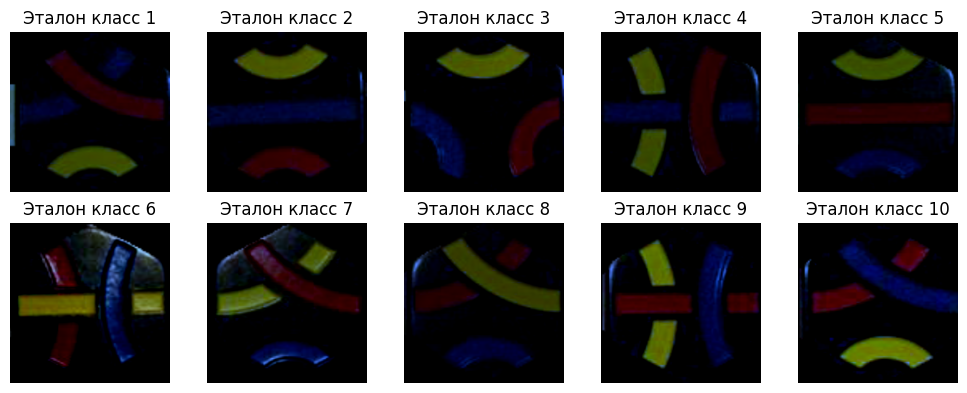

In [4]:
get_all_images_features(Image.open("all.bmp"))

In [5]:
all_images = np.load("all.npy")

# Проверка работоспособности алгоритма

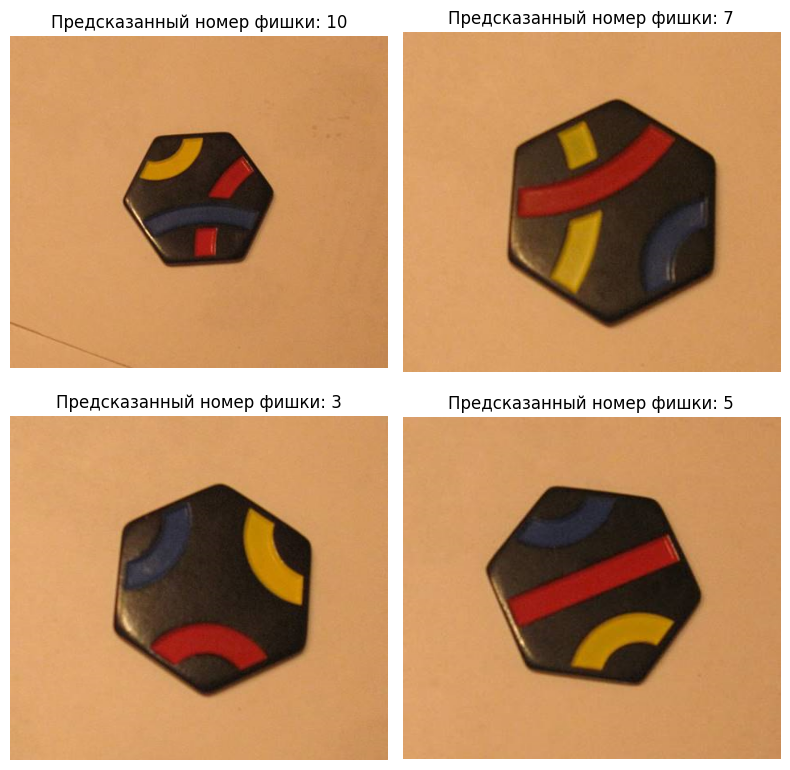

In [6]:
plt.figure(figsize=(8, 8))
for i in range(1, 5):
    plt.subplot(2, 2, i)
    image = Image.open(f"Single_{i}.bmp")
    plt.imshow(image)
    predict = processing(image, False)
    plt.title(f"Предсказанный номер фишки: {predict}")
    plt.axis("off")
plt.tight_layout()
plt.show()

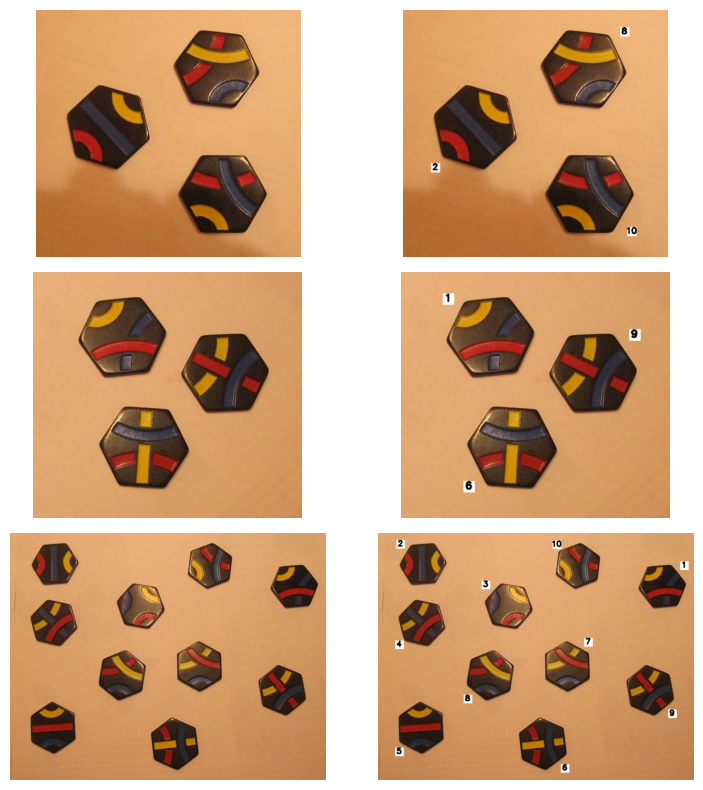

In [7]:
plt.figure(figsize=(8, 8))
for i in range(1, 6, 2):
    plt.subplot(3, 2, i)
    image = Image.open(f"Group_{i}.bmp")
    plt.imshow(image)
    plt.axis("off")
    plt.subplot(3, 2, i + 1)
    predict = processing(image, True)
    plt.imshow(predict)
    plt.axis("off")
plt.tight_layout()
plt.show()

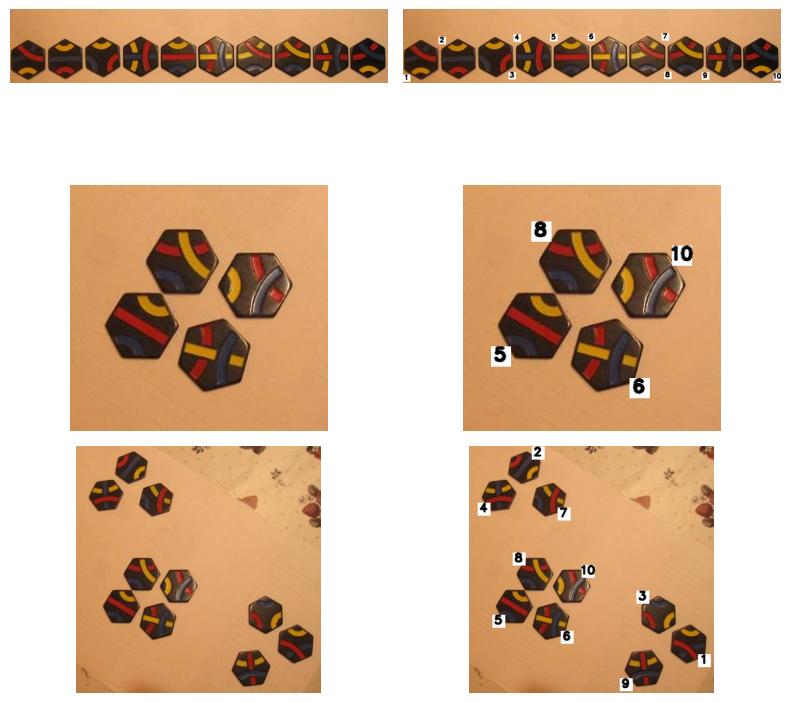

In [8]:
plt.figure(figsize=(8, 8))
for i in range(1, 6, 2):
    plt.subplot(3, 2, i)
    image = Image.open(f"Group_{i + 1}.bmp")
    plt.imshow(image)
    plt.axis("off")
    plt.subplot(3, 2, i + 1)
    predict = processing(image, True)
    plt.imshow(predict)
    plt.axis("off")
plt.tight_layout()
plt.show()